# DA2-MODEL-02 — Random Forest Classifier

> **Yêu cầu:** Chạy `DA2-MODEL-01` trước để tạo `sv4/shared/`

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Load dữ liệu từ MODEL-01
X_train_sc = np.load('/home/jovyan/work/sv4/shared/X_train_sc.npy')
X_test_sc  = np.load('/home/jovyan/work/sv4/shared/X_test_sc.npy')
y_train    = np.load('/home/jovyan/work/sv4/shared/y_train.npy')
y_test     = np.load('/home/jovyan/work/sv4/shared/y_test.npy')

print(f'Train: {X_train_sc.shape} | Test: {X_test_sc.shape}')

Train: (792, 7) | Test: (198, 7)


In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

print('=' * 45)
print('         RANDOM FOREST - KẾT QUẢ')
print('=' * 45)
print(classification_report(y_test, y_pred_rf, target_names=['Sell (0)', 'Buy (1)']))

# Lưu model và kết quả
with open('/home/jovyan/work/sv4/shared/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
np.save('/home/jovyan/work/sv4/shared/y_pred_rf.npy', y_pred_rf)
print('Đã lưu model vào sv4/shared/rf_model.pkl')

         RANDOM FOREST - KẾT QUẢ
              precision    recall  f1-score   support

    Sell (0)       0.85      0.22      0.35        78
     Buy (1)       0.66      0.97      0.79       120

    accuracy                           0.68       198
   macro avg       0.75      0.60      0.57       198
weighted avg       0.73      0.68      0.61       198

Đã lưu model vào sv4/shared/rf_model.pkl


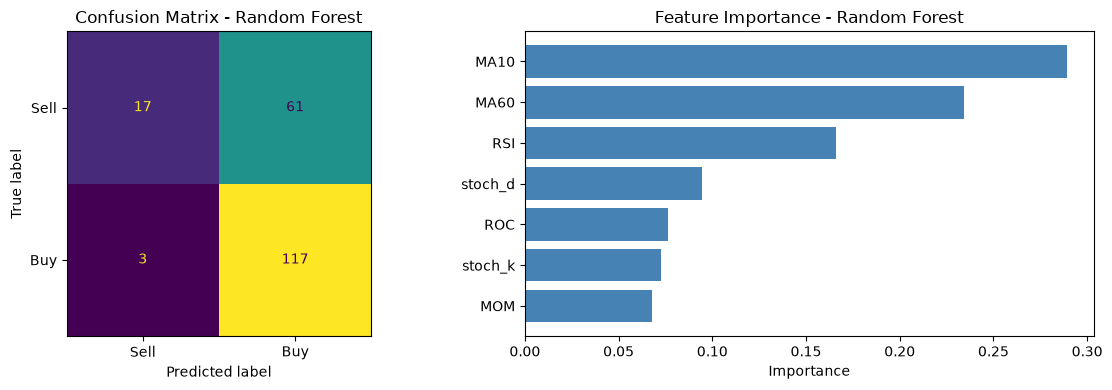

Accuracy: 0.6768


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=['Sell', 'Buy']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix - Random Forest')

# Feature Importance
FEATURES = ['MA10', 'MA60', 'ROC', 'MOM', 'RSI', 'stoch_k', 'stoch_d']
fi = sorted(zip(FEATURES, rf.feature_importances_), key=lambda x: x[1])
axes[1].barh([f[0] for f in fi], [f[1] for f in fi], color='steelblue')
axes[1].set_title('Feature Importance - Random Forest')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('/home/jovyan/work/sv4/DA2-MODEL-02/RF_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')